# Salient Object Detection (SOD) - Inference and Evaluation Notebook

This notebook demonstrates the full inference and evaluation pipeline for my **Salient Object Detection (SOD)** project.

The notebook covers:

- Loading the trained SOD model
- Loading train, validation, and test datasets
- Running inference on test images
- Visualizing predictions
- Computing segmentation metrics
- Summarizing final model performance

The project uses a custom CNN-based encoder–decoder architecture (SODCNN) to predict binary saliency masks from input images.

## 1. Configure Python Path

This cell adds the `src/` folder to Python's import path so project files such as `sod_model.py`, `data_loader.py`, and `config.py` can be imported directly from the notebook.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("SRC directory:", SRC_DIR)

Project root: C:\Users\Fatbardh\OneDrive\Documents\sod_project
SRC directory: C:\Users\Fatbardh\OneDrive\Documents\sod_project\src


## 2. Import Dependencies and Select Device

This cell imports the required libraries, loads the project modules, and selects the available device.

If CUDA is available, the notebook will use GPU. Otherwise, it will run on CPU.

# SOD Demo Notebook

This notebook is built for **your SOD project**, using your actual project classes:

- `SODCNN` from `src/sod_model.py`
- `SODDataset` from `src/data_loader.py`

It loads the trained model, prepares the dataset, visualizes predictions, and evaluates the model.

## 1. Configure Project Path

In [2]:
import sys
from pathlib import Path

# The notebook should be placed inside the main project folder.
PROJECT_ROOT = Path().resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("SRC directory:", SRC_DIR)
print("SRC exists:", SRC_DIR.exists())

Project root: C:\Users\Fatbardh\OneDrive\Documents\sod_project
SRC directory: C:\Users\Fatbardh\OneDrive\Documents\sod_project\src
SRC exists: True


## 2. Install Required Packages

Run this cell only if packages are missing. After it finishes, restart the kernel.

In [3]:
import sys

!{sys.executable} -m pip install torch torchvision torchaudio numpy matplotlib tqdm pillow

## 3. Import Dependencies

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import inspect
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

import config
from sod_model import SODCNN
from data_loader import SODDataset

IMAGE_SIZE = getattr(config, "IMAGE_SIZE", 128)
BATCH_SIZE = getattr(config, "BATCH_SIZE", 8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("SODCNN signature:", inspect.signature(SODCNN))
print("SODDataset signature:", inspect.signature(SODDataset))

Using device: cpu
Image size: 224
Batch size: 2
SODCNN signature: ()
SODDataset signature: (image_dir, mask_dir, img_size=224, augment=False)


## 4. Load the Trained Model

In [5]:
model = SODCNN().to(device)

checkpoint_path = PROJECT_ROOT / "models" / "best_model_20.pth"

if not checkpoint_path.exists():
    raise FileNotFoundError(f"Model not found at: {checkpoint_path}")

print("Loading model from:", checkpoint_path)

state_dict = torch.load(checkpoint_path, map_location=device)

# Handle case where model was saved as dict
if isinstance(state_dict, dict) and "model_state_dict" in state_dict:
    state_dict = state_dict["model_state_dict"]

model.load_state_dict(state_dict)
model.eval()

print("Model loaded successfully.")

Loading model from: C:\Users\Fatbardh\OneDrive\Documents\sod_project\models\best_model_20.pth
Model loaded successfully.


## 5. Find Dataset Folders

In [6]:
def find_existing_path(candidates):
    for path in candidates:
        if path.exists():
            return path
    return None


# Common SOD project folder structures.
train_img_dir = find_existing_path([
    PROJECT_ROOT / "data" / "train" / "images",
    PROJECT_ROOT / "dataset" / "train" / "images",
    PROJECT_ROOT / "MSRA10K" / "train" / "images",
    PROJECT_ROOT / "data" / "images" / "train",
])

train_mask_dir = find_existing_path([
    PROJECT_ROOT / "data" / "train" / "masks",
    PROJECT_ROOT / "dataset" / "train" / "masks",
    PROJECT_ROOT / "MSRA10K" / "train" / "masks",
    PROJECT_ROOT / "data" / "masks" / "train",
])

val_img_dir = find_existing_path([
    PROJECT_ROOT / "data" / "val" / "images",
    PROJECT_ROOT / "dataset" / "val" / "images",
    PROJECT_ROOT / "MSRA10K" / "val" / "images",
    PROJECT_ROOT / "data" / "images" / "val",
])

val_mask_dir = find_existing_path([
    PROJECT_ROOT / "data" / "val" / "masks",
    PROJECT_ROOT / "dataset" / "val" / "masks",
    PROJECT_ROOT / "MSRA10K" / "val" / "masks",
    PROJECT_ROOT / "data" / "masks" / "val",
])

test_img_dir = find_existing_path([
    PROJECT_ROOT / "data" / "test" / "images",
    PROJECT_ROOT / "dataset" / "test" / "images",
    PROJECT_ROOT / "MSRA10K" / "test" / "images",
    PROJECT_ROOT / "data" / "images" / "test",
])

test_mask_dir = find_existing_path([
    PROJECT_ROOT / "data" / "test" / "masks",
    PROJECT_ROOT / "dataset" / "test" / "masks",
    PROJECT_ROOT / "MSRA10K" / "test" / "masks",
    PROJECT_ROOT / "data" / "masks" / "test",
])

print("Train images:", train_img_dir)
print("Train masks: ", train_mask_dir)
print("Val images:  ", val_img_dir)
print("Val masks:   ", val_mask_dir)
print("Test images: ", test_img_dir)
print("Test masks:  ", test_mask_dir)

if test_img_dir is None or test_mask_dir is None:
    raise FileNotFoundError(
        "Could not automatically find test image/mask folders. "
        "Update the paths in this cell to match your project."
    )

Train images: C:\Users\Fatbardh\OneDrive\Documents\sod_project\data\train\images
Train masks:  C:\Users\Fatbardh\OneDrive\Documents\sod_project\data\train\masks
Val images:   C:\Users\Fatbardh\OneDrive\Documents\sod_project\data\val\images
Val masks:    C:\Users\Fatbardh\OneDrive\Documents\sod_project\data\val\masks
Test images:  C:\Users\Fatbardh\OneDrive\Documents\sod_project\data\test\images
Test masks:   C:\Users\Fatbardh\OneDrive\Documents\sod_project\data\test\masks


## 6. Create Dataset and DataLoader Objects

In [7]:
def create_dataset(image_dir, mask_dir):
    """
    Creates SODDataset using your project's constructor.
    This supports common constructor styles:
    SODDataset(image_dir, mask_dir)
    SODDataset(image_dir, mask_dir, image_size)
    SODDataset(image_dir=..., mask_dir=..., image_size=...)
    """
    try:
        return SODDataset(image_dir, mask_dir)
    except TypeError:
        pass

    try:
        return SODDataset(image_dir, mask_dir, IMAGE_SIZE)
    except TypeError:
        pass

    try:
        return SODDataset(image_dir=image_dir, mask_dir=mask_dir, image_size=IMAGE_SIZE)
    except TypeError:
        pass

    try:
        return SODDataset(images_dir=image_dir, masks_dir=mask_dir, image_size=IMAGE_SIZE)
    except TypeError:
        pass

    raise TypeError(
        "Could not create SODDataset automatically. "
        "Check the SODDataset constructor in src/data_loader.py."
    )


train_loader = None
val_loader = None

if train_img_dir is not None and train_mask_dir is not None:
    train_dataset = create_dataset(train_img_dir, train_mask_dir)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

if val_img_dir is not None and val_mask_dir is not None:
    val_dataset = create_dataset(val_img_dir, val_mask_dir)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = create_dataset(test_img_dir, test_mask_dir)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

if train_loader is not None:
    print("Train batches:", len(train_loader))
else:
    print("Train loader not created.")

if val_loader is not None:
    print("Validation batches:", len(val_loader))
else:
    print("Validation loader not created.")

print("Test batches:", len(test_loader))

Train batches: 350
Validation batches: 75
Test batches: 75


## 7. Helper Functions for Visualization

In [8]:
def tensor_to_image(tensor):
    """
    Convert a tensor to a NumPy image.
    Supports shapes: (C,H,W), (1,H,W), or (H,W).
    """
    array = tensor.detach().cpu().numpy()

    if array.ndim == 3:
        if array.shape[0] == 1:
            array = array.squeeze(0)
        else:
            array = np.transpose(array, (1, 2, 0))

    array = np.clip(array, 0, 1)
    return array


def make_overlay(image_np, mask_np, alpha=0.5):
    """
    Create a green prediction overlay on top of the original image.
    """
    image_np = image_np.astype(np.float32)
    mask_np = mask_np.astype(np.float32)

    if image_np.ndim == 2:
        image_np = np.stack([image_np, image_np, image_np], axis=-1)

    green_mask = np.zeros_like(image_np)
    green_mask[..., 1] = mask_np

    overlay = (1 - alpha) * image_np + alpha * green_mask
    overlay = np.clip(overlay, 0, 1)

    return overlay

## 8. Visualize One Random Test Prediction

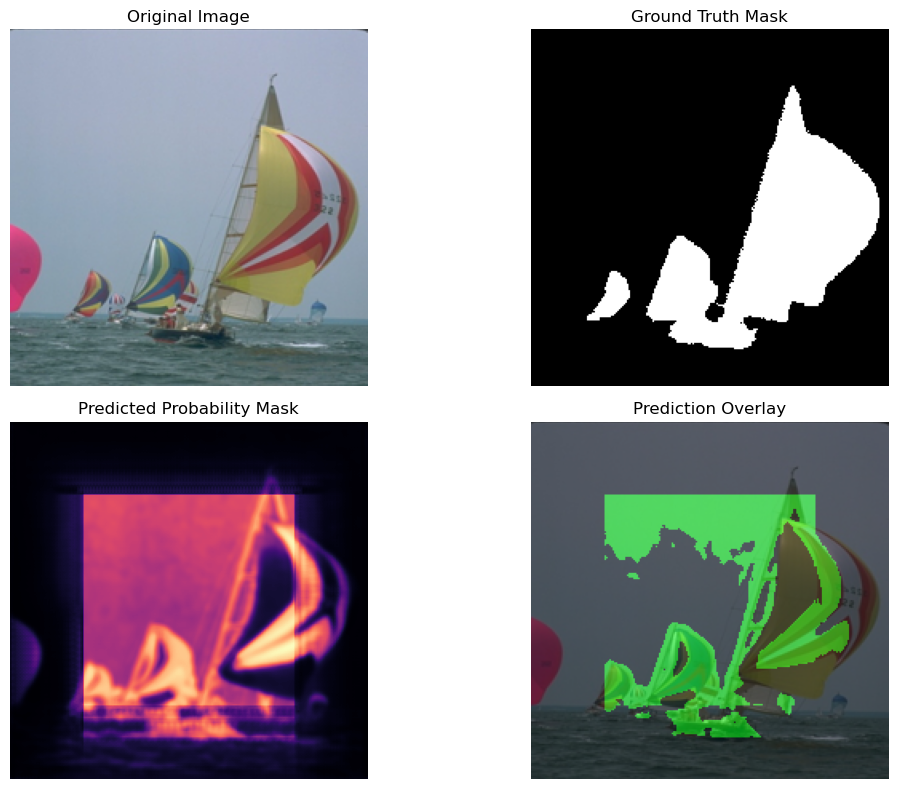

In [9]:
def show_random_test_example(threshold=0.5):
    model.eval()

    images, masks = next(iter(test_loader))
    index = random.randint(0, images.size(0) - 1)

    image = images[index].to(device)
    mask = masks[index].to(device)

    with torch.no_grad():
        prediction = model(image.unsqueeze(0))

    probability_mask = prediction.squeeze()
    binary_mask = (probability_mask >= threshold).float()

    image_np = tensor_to_image(image)
    mask_np = tensor_to_image(mask)
    prob_np = probability_mask.detach().cpu().numpy()
    binary_np = binary_mask.detach().cpu().numpy()

    overlay = make_overlay(image_np, binary_np)

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(image_np)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.imshow(prob_np, cmap="magma")
    plt.title("Predicted Probability Mask")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(overlay)
    plt.title("Prediction Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


show_random_test_example(threshold=0.5)

## 9. Evaluation Metrics

In [10]:
def batch_metrics(predictions, targets, eps=1e-7):
    """
    Compute IoU, Precision, Recall, F1-score, and MAE.
    """
    predictions = predictions.view(predictions.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    true_positive = (predictions * targets).sum(dim=1)
    false_positive = (predictions * (1 - targets)).sum(dim=1)
    false_negative = ((1 - predictions) * targets).sum(dim=1)

    union = true_positive + false_positive + false_negative

    iou = (true_positive + eps) / (union + eps)
    precision = (true_positive + eps) / (true_positive + false_positive + eps)
    recall = (true_positive + eps) / (true_positive + false_negative + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)

    mae = (predictions - targets).abs().mean(dim=1)

    return iou, precision, recall, f1, mae

## 10. Evaluate the Model on the Test Set

In [11]:
def evaluate_on_test(threshold=0.5):
    model.eval()

    iou_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    mae_scores = []

    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Evaluating test set"):
            images = images.to(device)
            masks = masks.to(device)

            predictions = model(images)
            binary_predictions = (predictions >= threshold).float()

            iou, precision, recall, f1, mae = batch_metrics(binary_predictions, masks)

            iou_scores.extend(iou.cpu().numpy().tolist())
            precision_scores.extend(precision.cpu().numpy().tolist())
            recall_scores.extend(recall.cpu().numpy().tolist())
            f1_scores.extend(f1.cpu().numpy().tolist())
            mae_scores.extend(mae.cpu().numpy().tolist())

    results = {
        "IoU": float(np.mean(iou_scores)),
        "Precision": float(np.mean(precision_scores)),
        "Recall": float(np.mean(recall_scores)),
        "F1-Score": float(np.mean(f1_scores)),
        "MAE": float(np.mean(mae_scores)),
    }

    print("Final Test Results")
    print("------------------")
    for metric, value in results.items():
        print(f"{metric}: {value:.4f}")

    return results


test_results = evaluate_on_test(threshold=0.5)

Evaluating test set:   0%|          | 0/75 [00:00<?, ?it/s]

Final Test Results
------------------
IoU: 0.4315
Precision: 0.5455
Recall: 0.7431
F1-Score: 0.5761
MAE: 0.2111


## 11. Show Multiple Test Predictions

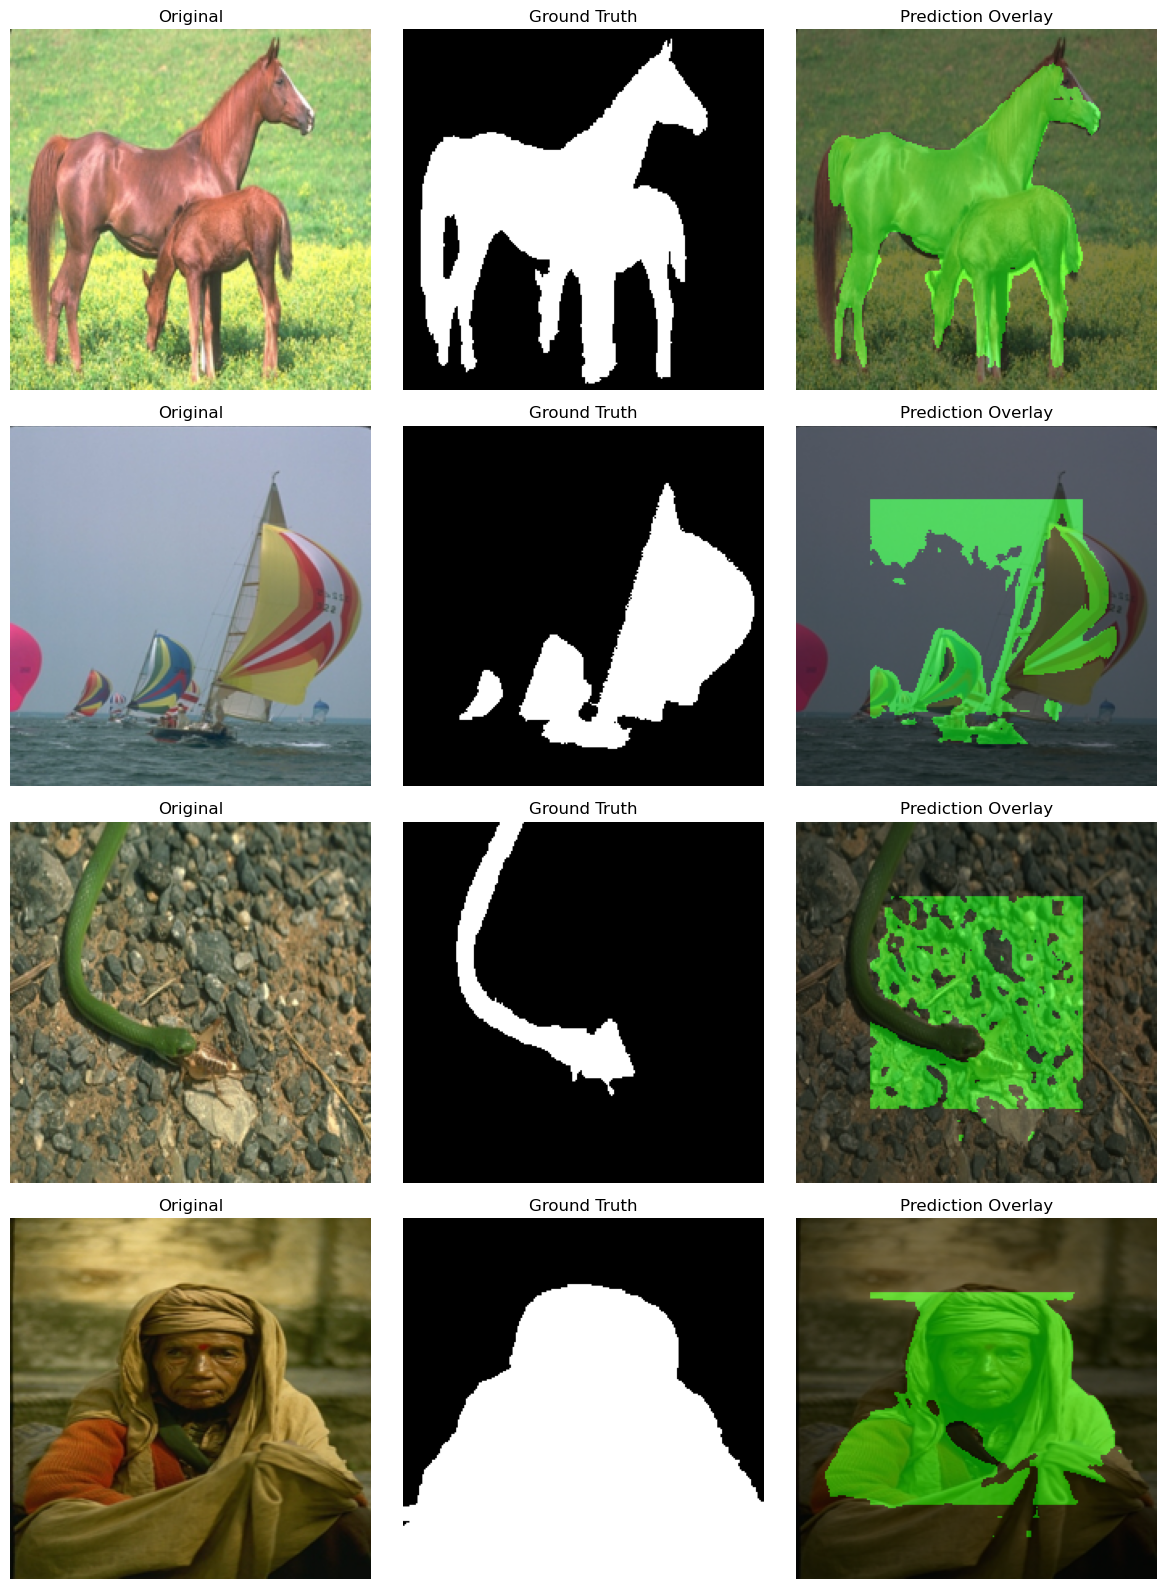

In [12]:
def show_test_grid(num_examples=4, threshold=0.5):
    model.eval()

    images_shown = 0
    rows = num_examples
    cols = 3

    plt.figure(figsize=(12, 4 * rows))

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)

            for i in range(images.size(0)):
                if images_shown >= num_examples:
                    plt.tight_layout()
                    plt.show()
                    return

                image = images[i]
                mask = masks[i]

                prediction = model(image.unsqueeze(0))
                probability_mask = prediction.squeeze()
                binary_mask = (probability_mask >= threshold).float()

                image_np = tensor_to_image(image)
                mask_np = tensor_to_image(mask)
                binary_np = binary_mask.detach().cpu().numpy()

                overlay = make_overlay(image_np, binary_np)

                row = images_shown

                plt.subplot(rows, cols, row * cols + 1)
                plt.imshow(image_np)
                plt.title("Original")
                plt.axis("off")

                plt.subplot(rows, cols, row * cols + 2)
                plt.imshow(mask_np, cmap="gray")
                plt.title("Ground Truth")
                plt.axis("off")

                plt.subplot(rows, cols, row * cols + 3)
                plt.imshow(overlay)
                plt.title("Prediction Overlay")
                plt.axis("off")

                images_shown += 1

    plt.tight_layout()
    plt.show()


show_test_grid(num_examples=4, threshold=0.5)

## 12. Final Summary

In [16]:
print("""
## SOD Demo Notebook Summary

This notebook demonstrates the final implementation of the SOD project:

- Model class: SODCNN  
- Dataset class: SODDataset  

### The notebook includes:

1. Project path configuration  
2. Model checkpoint loading  
3. Dataset and DataLoader creation  
4. Single-image prediction visualization  
5. Full test-set evaluation  
6. Multi-image prediction grid  

### Evaluation metrics:

- IoU  
- Precision  
- Recall  
- F1-score  
- MAE  
""")


## SOD Demo Notebook Summary

This notebook demonstrates the final implementation of the SOD project:

- Model class: SODCNN  
- Dataset class: SODDataset  

### The notebook includes:

1. Project path configuration  
2. Model checkpoint loading  
3. Dataset and DataLoader creation  
4. Single-image prediction visualization  
5. Full test-set evaluation  
6. Multi-image prediction grid  

### Evaluation metrics:

- IoU  
- Precision  
- Recall  
- F1-score  
- MAE  

